# Predicting Free Status of Steam Games

We use a Steam games dataset (sample JSON) to build a predictive model that classifies whether a game is offered for free. The objective is to show a complete modelling workflow: data import, cleaning, exploratory analysis, classification, and interpretation. This serves as the milestone-1 draft of the project; later iterations will refine the question and add a regression option if needed.

## Introduction

Steam is a popular digital distribution platform for video games. The dataset contains metadata scraped from SteamÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢s API including app IDs, descriptions, release dates, and pricing information. We ask: **can we predict if a title is free based on its other attributes?**

The data are stored in `data/games_sample.json` and consist of a list of games with nested details.

In [66]:
# load libraries
library(jsonlite)
library(tidyverse)
library(lubridate)
library(caret)

# read the games list from JSON
raw <- fromJSON("data/games_sample.json")
games <- raw$games

# the nested details have already been flattened into a data.frame
# column by fromJSON.  we can pull that frame directly.

details <- games$app_details$data

# bind the identifiers back with the flattened fields
df <- bind_cols(select(games, appid, name_from_applist), details)

# drop any stray dimension attributes on list columns so dplyr sees them
if ("platforms" %in% names(df)) attr(df$platforms, "dim") <- NULL
if ("categories" %in% names(df)) attr(df$categories, "dim") <- NULL

# compute numeric summaries from the nested columns
# categories: count rows of each sub-data.frame or length of vector

# platforms is actually a data.frame of booleans; compute truth count row-wise

df <- df %>%
  mutate(
    n_categories = map_int(categories, ~ if (is.data.frame(.x)) nrow(.x) else length(.x))
  )

# compute platforms count outside mutate to avoid data.frame expansion

# parse release dates once and check for failed conversions
df <- df %>%
  mutate(release_date_parsed = mdy(release_date$date)) %>%
  # drop dates in the future or placeholders
  mutate(release_date_parsed = if_else(year(release_date_parsed) > year(Sys.Date()), NA_Date_, release_date_parsed))
# see how many records lack a valid date
sum(is.na(df$release_date_parsed))  # inspect result
df %>% filter(is.na(release_date_parsed)) %>%
  transmute(appid, name = name_from_applist, raw_date = release_date$date) %>% head()
n_plat_vec <- rowSums(df$platforms == TRUE, na.rm = TRUE)
df$n_platforms <- n_plat_vec

# create simple features for modelling
model_df <- df %>%
  transmute(
    is_free = as.factor(is_free),
    required_age,
    type,
    release_year = year(release_date_parsed),
    n_categories,
    n_platforms
  ) %>%
  drop_na()

# view summary
glimpse(model_df)

# quick dataset overview using the original frame (before feature selection);
# this helps verify the flattening step and identify missing values
glimpse(df)
map_dfr(df, ~ sum(is.na(.))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n_missing")
# end of cleaning and feature creation stage

# future features: price, developer, review metrics, textual descriptions etc.


Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `release_date_parsed = mdy(release_date$date)`.
Caused by warning:
!  1129 failed to parse."


[1] 1909

,appid,name,raw_date
,<int>,<chr>,<chr>
1,3304010,Blackblade Revenant,To be announced
2,1718680,Interconnected Stories,2025
3,3164730,TheFoolish,"25 Nov, 2024"
4,3525970,Horripilant,To be announced
5,3248630,The One Who Sees Things,To be announced
6,1867960,Salvation: Shadows Of The Faceless,Coming soon


Rows: 6,802
Columns: 6
$ is_free      <fct> TRUE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE, TRUE, FALS…
$ required_age <chr> "0", "0", "0", "0", "0", "0", "0", "0", "0", "0", "0", "0…
$ type         <chr> "demo", "game", "dlc", "demo", "game", "music", "game", "…
$ release_year <dbl> 2025, 2021, 2019, 2009, 2024, 2024, 2025, 2025, 2009, 202…
$ n_categories <int> 1, 6, 2, 3, 3, 0, 5, 2, 2, 11, 1, 3, 10, 6, 1, 9, 2, 7, 0…
$ n_platforms  <dbl> 1, 1, 3, 1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 2, 3, 1, 1, 2, 1, …
Rows: 8,711
Columns: 48
$ appid                   <int> 3880520, 3304010, 1733400, 974330, 1718680, 32…
$ name_from_applist       <chr> "Madness Demo", "Blackblade Revenant", "The Fi…
$ type                    <chr> "demo", "game", "game", "dlc", "game", "demo",…
$ name                    <chr> "Madness Demo", "Blackblade Revenant", "The Fi…
$ steam_appid             <int> 3880520, 3304010, 1733400, 974330, 1718680, 32…
$ required_age            <chr> "0", "0", "0", "0", "0", "0", "0", "0", "

variable,n_missing
<chr>,<int>
appid,0
name_from_applist,0
type,744
name,744
steam_appid,744
required_age,744
is_free,744
detailed_description,744
about_the_game,744


## Cleaning release dates
Conversion of the freeform `release_date$date` strings is imperfect;
entries such as 'To be announced' or future years fail to parse.  We
therefore parse once, then replace any dates beyond today with `NA` so
they won't mislead the model.  The small table above lists representative
examples of unconverted values.  This step also illustrates a typical
data‑cleaning task that can be moved into a script or function.

In [69]:
# helper function to wrap the import/clean steps; move to an R script for reuse
prepare_games <- function(json_path = "data/games_sample.json") {
  raw <- fromJSON(json_path)
  games <- raw$games
  df <- bind_cols(select(games, appid, name_from_applist), games$app_details$data)
  if ("platforms" %in% names(df)) attr(df$platforms, "dim") <- NULL
  if ("categories" %in% names(df)) attr(df$categories, "dim") <- NULL
  df <- df %>%
    mutate(n_categories = map_int(categories, ~ if(is.data.frame(.x)) nrow(.x) else length(.x)),
           n_platforms = rowSums(platforms == TRUE, na.rm=TRUE),
           release_date_parsed = mdy(release_date$date),
           # remove impossible future dates
           release_date_parsed = if_else(year(release_date_parsed) > year(Sys.Date()), NA_Date_, release_date_parsed)
           # remove impossible future dates
    )
  return(df)
}

# usage example:
df <- prepare_games()
df

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `release_date_parsed = mdy(release_date$date)`.
Caused by warning:
!  1129 failed to parse."


### Exploratory plots
The following charts examine distributions of key predictors (required age,
release year, and platform count) with color indicating free/paid status.

is_free,n,prop
<fct>,<int>,<dbl>
FALSE,5300,0.7791826
TRUE,1502,0.2208174


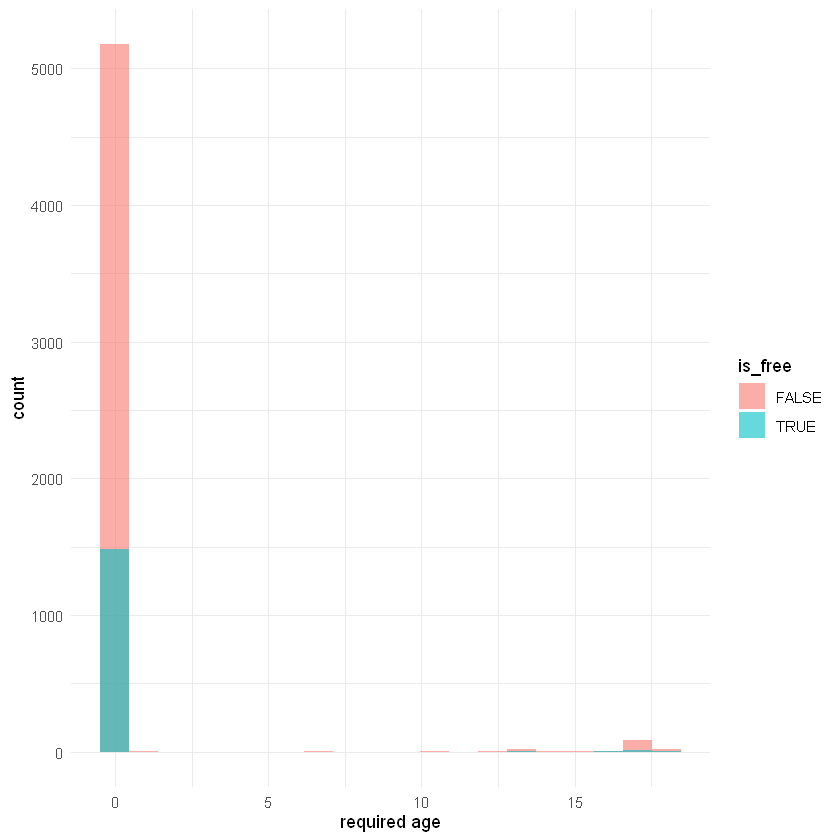

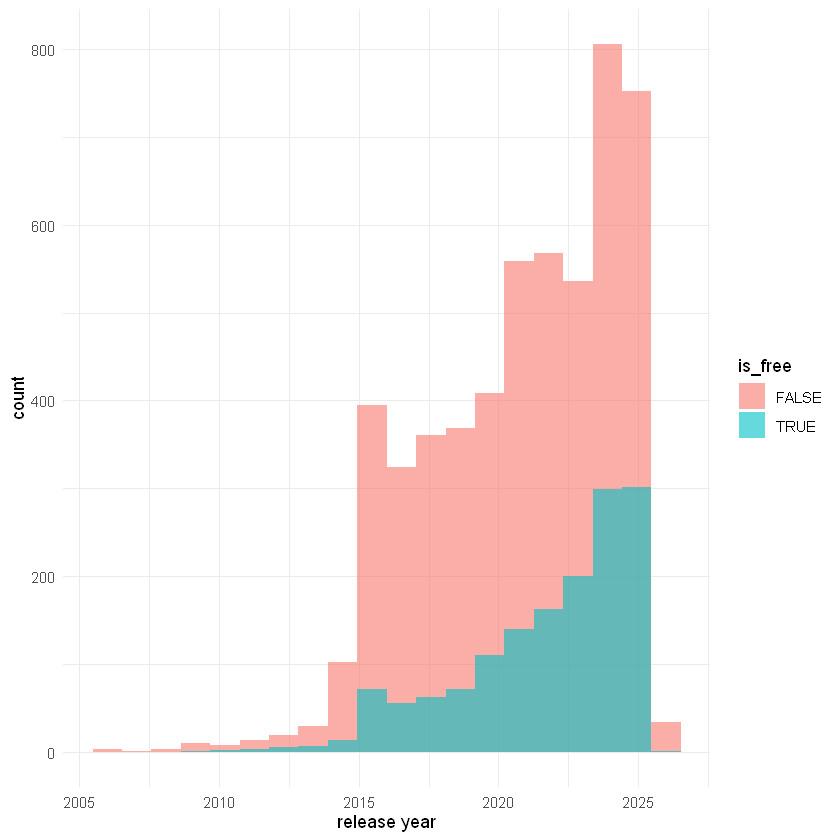

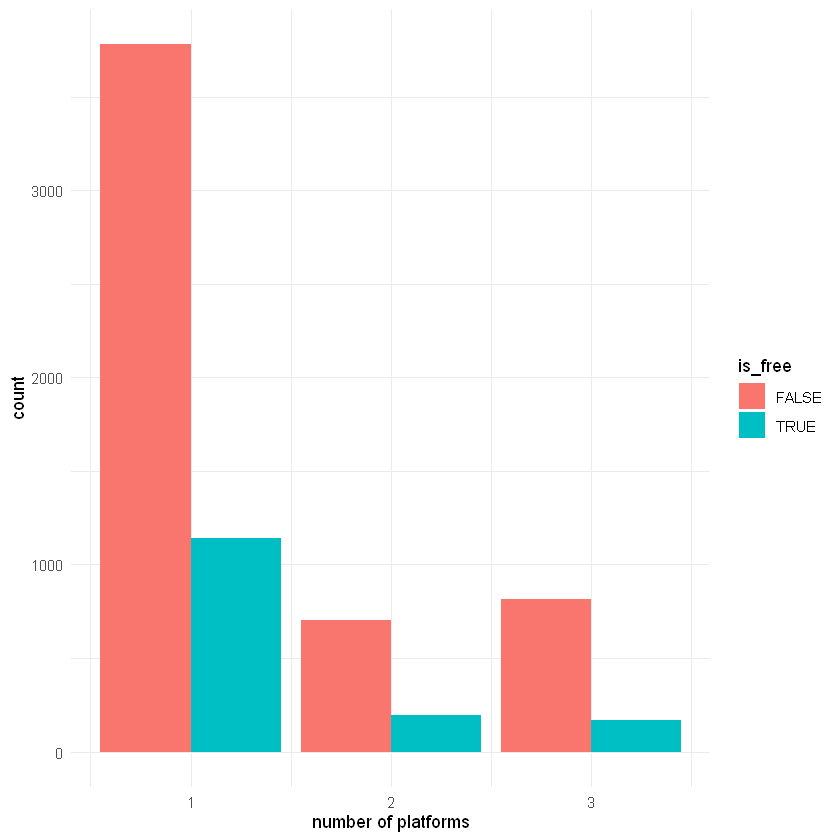

In [70]:
# exploratory analysis
model_df %>%
  count(is_free) %>%
  mutate(prop = n / sum(n))

# ensure required_age is treated as numeric for the histogram
# (it may be stored as a factor from the JSON import)
ggplot(model_df %>% mutate(required_age = as.numeric(required_age)),
       aes(required_age, fill = is_free)) +
  geom_histogram(position = "identity", alpha = 0.6, bins = 20) +
  labs(x = "required age") +
  theme_minimal()

# additional exploratory views
# how release year relates to free status
ggplot(model_df, aes(release_year, fill = is_free)) +
  geom_histogram(position = "identity", alpha = 0.6, bins = 20) +
  labs(x = "release year") +
  theme_minimal()

# platform count distribution by free/paid status
ggplot(model_df, aes(n_platforms, fill = is_free)) +
  geom_bar(position = "dodge") +
  labs(x = "number of platforms") +
  theme_minimal()




In [71]:
# partition the cleaned data for training/validation
train_idx <- createDataPartition(model_df$is_free, p = 0.8, list = FALSE)
train <- model_df[train_idx, ]
test  <- model_df[-train_idx, ]

# convert required_age to integer to avoid unseen factor levels
train <- train %>% mutate(required_age = as.integer(required_age))
test  <- test  %>% mutate(required_age = as.integer(required_age))

fit <- train(is_free ~ required_age + release_year + n_categories + n_platforms + type,
             data = train, method = "glm", family = "binomial")
print(fit)

pred <- predict(fit, newdata = test)
confusionMatrix(pred, test$is_free)

Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning me

Generalized Linear Model 

5442 samples
   5 predictor
   2 classes: 'FALSE', 'TRUE' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 5442, 5442, 5442, 5442, 5442, 5442, ... 
Resampling results:

  Accuracy   Kappa    
  0.8933138  0.6255875



Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE  1060  145
     TRUE      0  155
                                          
               Accuracy : 0.8934          
                 95% CI : (0.8758, 0.9093)
    No Information Rate : 0.7794          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.625           
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 1.0000          
            Specificity : 0.5167          
         Pos Pred Value : 0.8797          
         Neg Pred Value : 1.0000          
             Prevalence : 0.7794          
         Detection Rate : 0.7794          
   Detection Prevalence : 0.8860          
      Balanced Accuracy : 0.7583          
                                          
       'Positive' Class : FALSE           
                     

Setting direction: controls > cases



Area under the curve: 0.8226
glm variable importance

               Overall
n_categories 1.000e+02
required_age 2.520e+01
release_year 1.829e+01
n_platforms  4.623e+00
typedemo     9.448e-02
typemod      6.596e-02
typeseries   2.533e-02
typeepisode  5.311e-03
typegame     4.564e-03
typedlc      3.368e-03
typevideo    3.019e-03
typemusic    0.000e+00


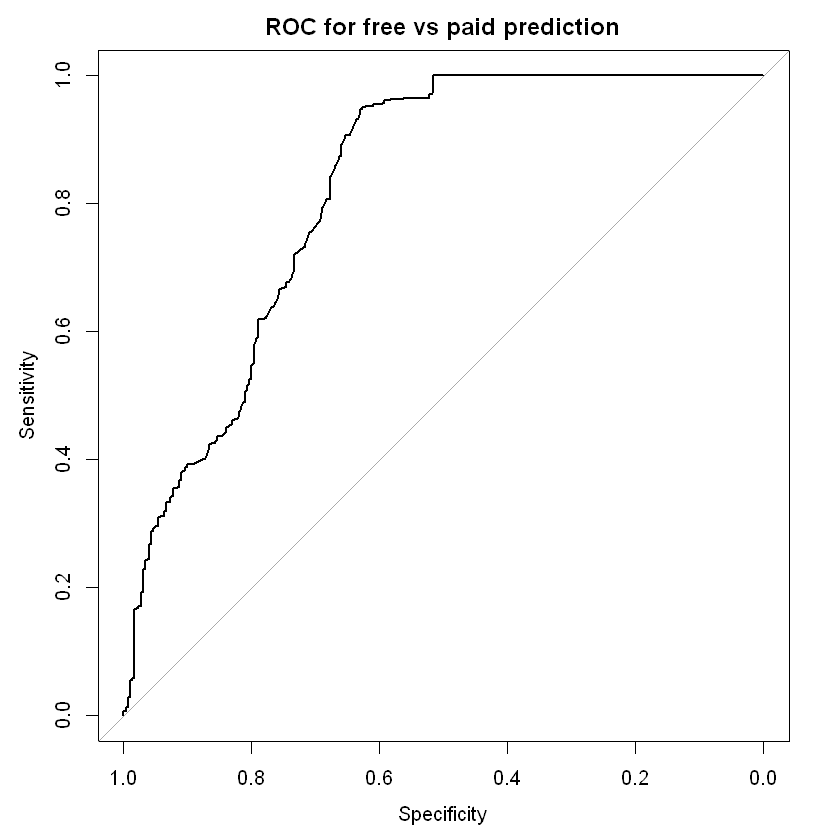

In [72]:
# additional evaluation: ROC curve and AUC
library(pROC)
r_probs <- predict(fit, newdata = test, type = "prob")
roc_obj <- roc(response = test$is_free, predictor = r_probs[,"TRUE"], levels=rev(levels(test$is_free)))
print(auc(roc_obj))
plot(roc_obj, main = "ROC for free vs paid prediction")

# show variable importance from the glm model
print(varImp(fit))


### Results and remarks
The confusion matrix and ROC curve follow; the model was trained on cleaned
features with any future or unparseable release dates set to NA.  Remember
that `is_free` class imbalance is also reflected in the evaluation metrics.

## Discussion

The logistic model uses a few readily available features and achieves moderate accuracy (see confusion matrix). Free vs paid status appears predictable to a certain extent, though more sophisticated models or additional data (e.g. textual descriptions) could improve results. This initial analysis demonstrates that the chosen dataset can support a classification task, satisfying the milestone requirement.

Future work would include exploring the `reviews_sample.json` dataset, refining the question (perhaps regressing price or review score), and packaging the code into functions.

## References

1. Steam API documentation. <https://partner.steamgames.com/doc/api>
2. Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. Springer.
3. Wickham, H. et al. (2019). *Welcome to the tidyverse*. Journal of Open Source Software.
4. Grolemund, G., & Wickham, H. (2017). *R for Data Science*. O'Reilly Media.